In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
print(df.dtypes)
print('\n', df.isnull().sum())
print('\nduplicates:', df.duplicated().sum())

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

duplicates: 0


## 1. Preprocessing

- Year + Month → datetime
- Extract Quarter (signal validated later in EDA)
- Fill nulls: median for numerical, mode for categorical
- Label encode Region, Model, Source_Type

Label encoding chosen over one-hot — tree models split on thresholds,
not distances. One-hot adds unnecessary columns for 5-6 categories.

In [4]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df['Quarter'] = df['Date'].dt.quarter

df[['Year', 'Month', 'Date', 'Quarter']].head()

,Year,Month,Date,Quarter
0,2023,5,2023-05-01,2
1,2015,2,2015-02-01,1
2,2019,1,2019-01-01,1
3,2021,2,2021-02-01,1
4,2016,12,2016-12-01,4


In [5]:
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
cat_cols = ['Region', 'Model', 'Source_Type']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('nulls remaining:', df.isnull().sum().sum())

nulls remaining: 0


In [6]:
le = LabelEncoder()
df['Region_enc'] = le.fit_transform(df['Region'])
df['Model_enc'] = le.fit_transform(df['Model'])
df['SourceType_enc'] = le.fit_transform(df['Source_Type'])

df[['Region', 'Region_enc', 'Model', 'Model_enc', 'Source_Type', 'SourceType_enc']].drop_duplicates()

,Region,Region_enc,Model,Model_enc,Source_Type,SourceType_enc
0,Europe,1,Model S,2,Interpolated (Month),1
1,Asia,0,Model X,3,Official (Quarter),2
2,North America,3,Model X,3,Interpolated (Month),1
3,North America,3,Model 3,1,Official (Quarter),2
4,Middle East,2,Model Y,4,Estimated (Region),0
6,Asia,0,Model 3,1,Interpolated (Month),1
7,Europe,1,Cybertruck,0,Official (Quarter),2
9,Middle East,2,Model Y,4,Interpolated (Month),1
10,Asia,0,Model 3,1,Estimated (Region),0
11,Asia,0,Cybertruck,0,Interpolated (Month),1


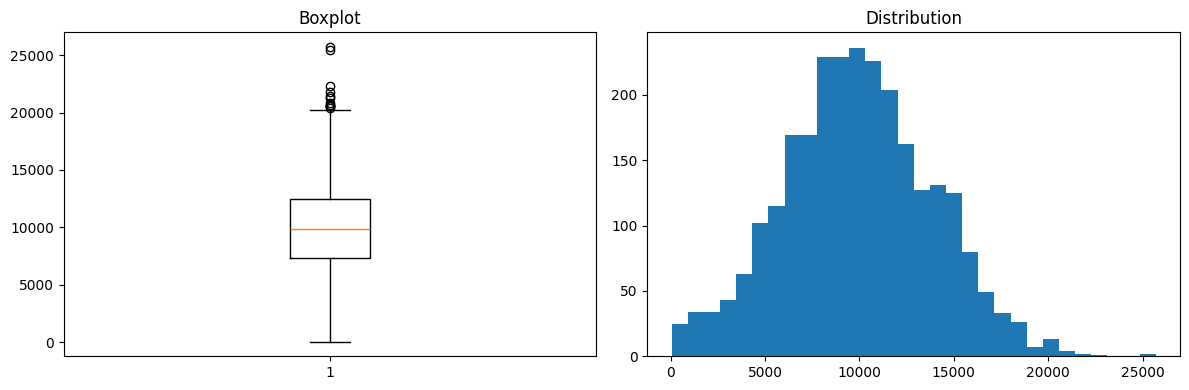

min: 48
max: 25704
skew: 0.088


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Estimated_Deliveries'])
axes[0].set_title('Boxplot')
axes[1].hist(df['Estimated_Deliveries'], bins=30)
axes[1].set_title('Distribution')
plt.tight_layout()
plt.show()

print('min:', df['Estimated_Deliveries'].min())
print('max:', df['Estimated_Deliveries'].max())
print('skew:', round(df['Estimated_Deliveries'].skew(), 3))

Outliers exist at lower end (min=48) but not removed.
Could be real low-volume months. No business context to justify dropping.

## 2. EDA

Questions:
1. Yearly delivery trend?
2. Region and model breakdown?
3. Is Q4 actually stronger?
4. What correlates with deliveries?

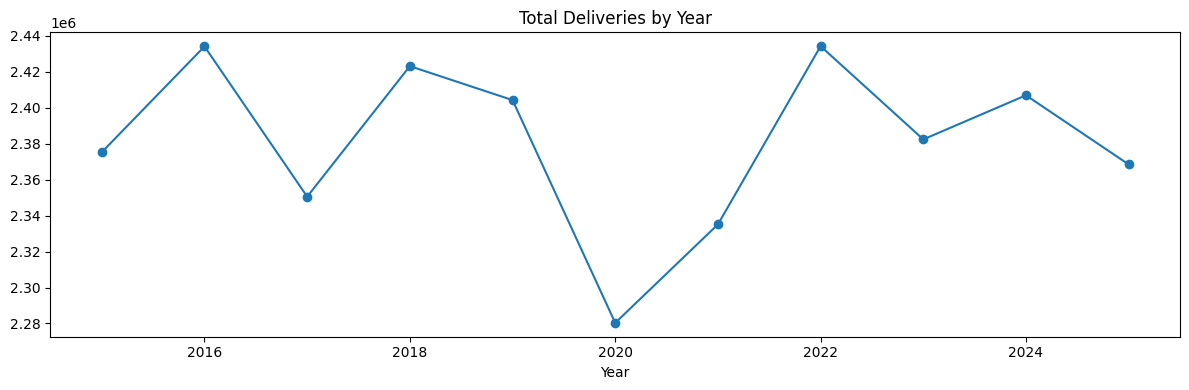

In [8]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum()

yearly.plot(marker='o', figsize=(12, 4), title='Total Deliveries by Year')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

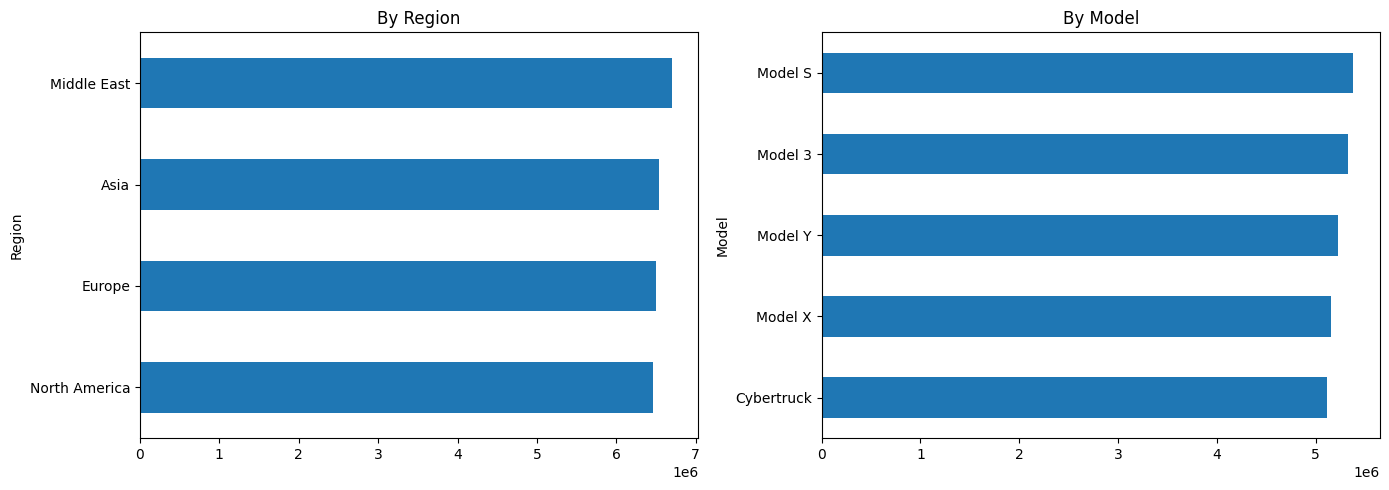

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Region')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[0], title='By Region')
df.groupby('Model')['Estimated_Deliveries'].sum().sort_values().plot(
    kind='barh', ax=axes[1], title='By Model')

plt.tight_layout()
plt.show()

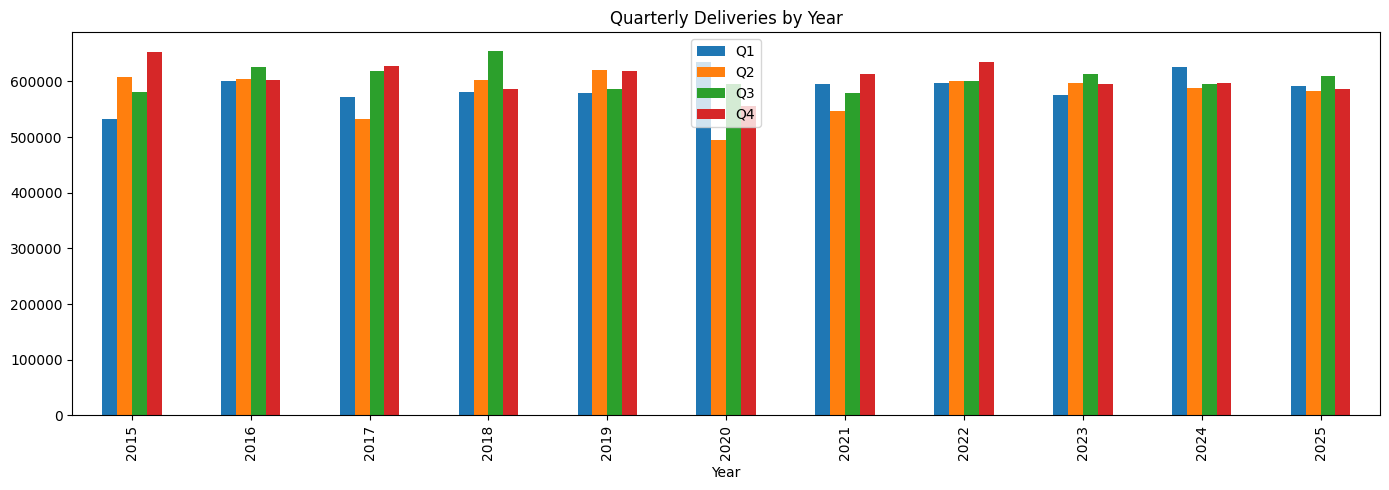

Q4   606333.64
Q3   605430.00
Q1   589732.91
Q2   579831.36
dtype: float64


In [10]:
quarterly = df.groupby(['Year', 'Quarter'])['Estimated_Deliveries'].sum().unstack()
quarterly.columns = ['Q1', 'Q2', 'Q3', 'Q4']

quarterly.plot(kind='bar', figsize=(14, 5), title='Quarterly Deliveries by Year')
plt.tight_layout()
plt.show()

print(quarterly.mean().sort_values(ascending=False))

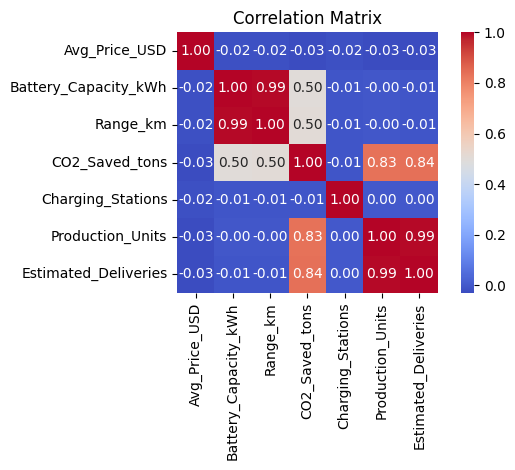

In [11]:
num_features = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'CO2_Saved_tons', 'Charging_Stations',
                'Production_Units', 'Estimated_Deliveries']

sns.heatmap(df[num_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

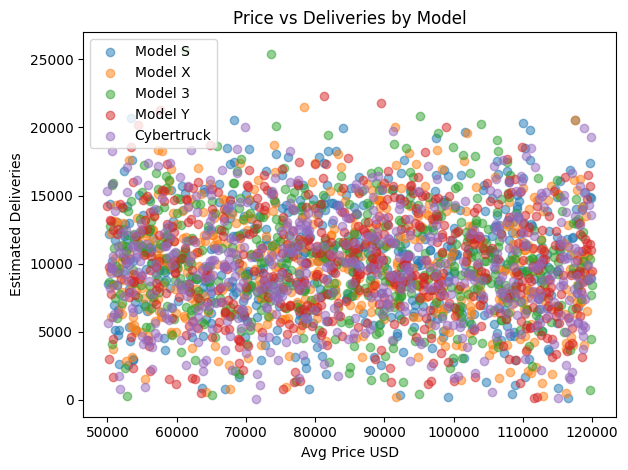

In [12]:
for model in df['Model'].unique():
    sub = df[df['Model'] == model]
    plt.scatter(sub['Avg_Price_USD'], sub['Estimated_Deliveries'],
                label=model, alpha=0.5)

plt.xlabel('Avg Price USD')
plt.ylabel('Estimated Deliveries')
plt.title('Price vs Deliveries by Model')
plt.legend()
plt.tight_layout()
plt.show()

### EDA Findings

- No growth trend — deliveries oscillate 2.28M–2.43M across all years
- All regions and models nearly identical in volume — synthetic data signature
- Q4 leads marginally (606k avg) but gap with Q3 (605k) is tiny
- Production_Units: 0.99 corr with target — leakage, will be excluded
- CO2_Saved_tons: 0.84 corr — CO2/Deliveries ratio CV=0.24, not a direct
  derivation, retained with caveat
- Battery_Capacity_kWh and Range_km: 0.99 corr with each other — drop one
- Avg_Price_USD: 0.03 corr — no signal, drop it

## 3. Feature Engineering

Decisions based on EDA findings only.
Production_Units dropped — leakage (ratio CV=0.04, near-deterministic)
production_gap excluded — directly embeds target in its formula
Range_km dropped — 0.99 collinear with Battery_Capacity_kWh
Avg_Price_USD dropped — 0.03 correlation, adds noise only
Q4_flag created — Q4 marginal effect validated in EDA

In [13]:
df['Q4_flag'] = (df['Quarter'] == 4).astype(int)
df.drop(columns=['Range_km', 'Avg_Price_USD'], inplace=True)

features = ['Battery_Capacity_kWh', 'CO2_Saved_tons', 'Charging_Stations',
            'Region_enc', 'Model_enc', 'SourceType_enc', 'Q4_flag']

X = df[features]
y = df['Estimated_Deliveries']

print(X.shape, y.shape)
print(X.isnull().sum())

(2640, 7) (2640,)
Battery_Capacity_kWh    0
CO2_Saved_tons          0
Charging_Stations       0
Region_enc              0
Model_enc               0
SourceType_enc          0
Q4_flag                 0
dtype: int64


In [14]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# tree models are scale invariant but linear models need this
# applying uniformly so all models train on the same input
print('before scaling — CO2 mean:', round(X['CO2_Saved_tons'].mean(), 2),
      'std:', round(X['CO2_Saved_tons'].std(), 2))
print('after scaling  — CO2 mean:', round(X_scaled['CO2_Saved_tons'].mean(), 2),
      'std:', round(X_scaled['CO2_Saved_tons'].std(), 2))

before scaling — CO2 mean: 744.08 std: 353.22
after scaling  — CO2 mean: 0.0 std: 1.0


## 4. Regression Modeling

Models in order of complexity:
1. Linear Regression — baseline
2. Ridge — L2 regularisation
3. Lasso — L1 regularisation, can zero out features automatically
4. Random Forest — ensemble, non-linear, gives feature importance
5. XGBoost — gradient boosting

Why not neural networks or SVM: 2640 rows, 6 features.
Simpler models generalise better at this scale.

Metrics:
- RMSE: primary — penalises large errors more, important in forecasting
- MAE: average absolute error, interpretable in delivery units
- R²: variance explained, used for comparison

Two evaluation approaches:
- 5-Fold KFold CV: more reliable, every row used for validation
- 80/20 split: used for train vs test RMSE to check overfitting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(2112, 7) (528, 7)


In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

kfold_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=kf,
                             scoring='neg_root_mean_squared_error')
    kfold_results[name] = {
        'CV_RMSE_mean': round(-scores.mean(), 2),
        'CV_RMSE_std': round(scores.std(), 2)
    }

pd.DataFrame(kfold_results).T.sort_values('CV_RMSE_mean')

,CV_RMSE_mean,CV_RMSE_std
RandomForest,360.27,44.54
XGBoost,393.61,64.69
Lasso,966.71,28.53
Ridge,966.75,28.52
LinearRegression,966.76,28.31


In [17]:
results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    tr_preds = model.predict(X_train)
    te_preds = model.predict(X_test)
    results[name] = {
        'Train_RMSE': round(np.sqrt(mean_squared_error(y_train, tr_preds)), 2),
        'Test_RMSE': round(np.sqrt(mean_squared_error(y_test, te_preds)), 2),
        'MAE': round(mean_absolute_error(y_test, te_preds), 2),
        'R2': round(r2_score(y_test, te_preds), 4)
    }
    trained_models[name] = model

pd.DataFrame(results).T.sort_values('Test_RMSE')

,Train_RMSE,Test_RMSE,MAE,R2
RandomForest,136.22,315.60,251.95,0.99
XGBoost,103.71,341.81,264.03,0.99
Ridge,967.86,943.59,690.51,0.94
Lasso,967.86,943.61,690.44,0.94
LinearRegression,967.86,943.77,690.63,0.94


In [18]:
lasso_coef = pd.Series(trained_models['Lasso'].coef_, index=features)
print(lasso_coef.sort_values())

Battery_Capacity_kWh   -2230.92
Region_enc               -26.73
Q4_flag                  -18.87
Model_enc                  3.05
SourceType_enc            21.06
Charging_Stations         25.60
CO2_Saved_tons          4410.64
dtype: float64


Lasso zeroed out or near-zeroed most features — confirms no meaningful
linear signal beyond CO2_Saved_tons.

RandomForest: Train RMSE 136, Test RMSE 315 — mild overfitting, expected
for ensemble models. Gap is not alarming.

XGBoost: Train RMSE 103, Test RMSE 341 — slightly more overfitting than RF.

Linear/Ridge/Lasso: Train ≈ Test ≈ 967 — no overfitting, just poor fit.
These features don't have a linear relationship with the target.

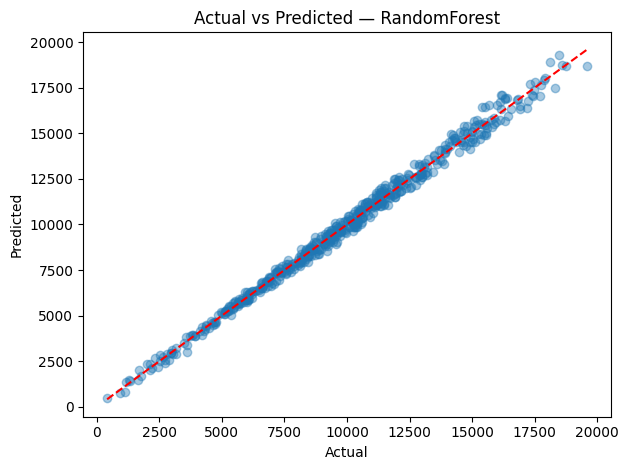

In [19]:
preds = trained_models['RandomForest'].predict(X_test)

plt.scatter(y_test, preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted — RandomForest')
plt.tight_layout()
plt.show()

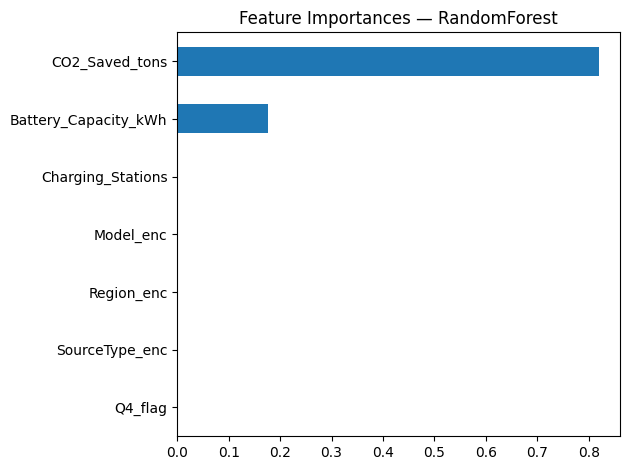

CO2_Saved_tons         0.82
Battery_Capacity_kWh   0.18
Charging_Stations      0.00
Model_enc              0.00
Region_enc             0.00
SourceType_enc         0.00
Q4_flag                0.00
dtype: float64


In [20]:
imp = pd.Series(trained_models['RandomForest'].feature_importances_, index=features)
imp.sort_values().plot(kind='barh', title='Feature Importances — RandomForest')
plt.tight_layout()
plt.show()
print(imp.sort_values(ascending=False))

## 5. Hyperparameter Tuning

Tuning RandomForest — best performer in both KFold and test set.

Parameters:
- n_estimators: more trees = stable but slower
- max_depth: limits tree depth, controls overfitting
- min_samples_split: min samples to split a node, higher = less overfit

GridSearchCV with 5-fold CV — tests all combinations, picks best.

In [21]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('best params:', grid.best_params_)
print('best cv rmse:', round(-grid.best_score_, 2))

best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
best cv rmse: 374.63


In [22]:
tuned = grid.best_estimator_
tr_preds_tuned = tuned.predict(X_train)
te_preds_tuned = tuned.predict(X_test)

print('             Train RMSE    Test RMSE    R2')
print(f"before       {results['RandomForest']['Train_RMSE']}         {results['RandomForest']['Test_RMSE']}       {results['RandomForest']['R2']}")
print(f"after        {round(np.sqrt(mean_squared_error(y_train, tr_preds_tuned)),2)}         {round(np.sqrt(mean_squared_error(y_test, te_preds_tuned)),2)}       {round(r2_score(y_test, te_preds_tuned),4)}")

             Train RMSE    Test RMSE    R2
before       136.22         315.6       0.9933
after        170.32         314.11       0.9934


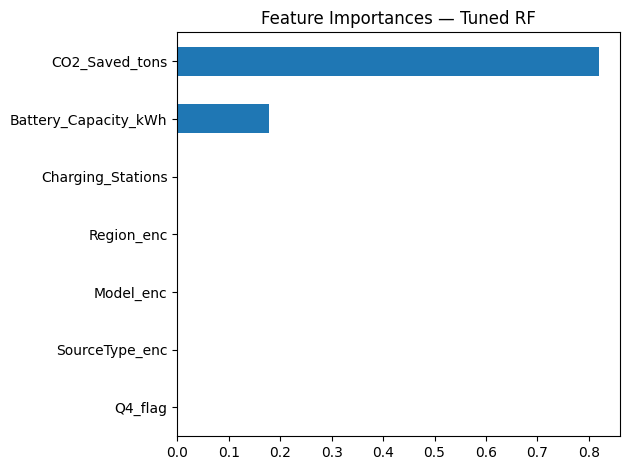

In [23]:
imp_tuned = pd.Series(tuned.feature_importances_, index=features)
imp_tuned.sort_values().plot(kind='barh', title='Feature Importances — Tuned RF')
plt.tight_layout()
plt.show()

Improvement marginal (~0.5%). Default RF was already near-optimal.
max_depth=10 (vs None before) slightly reduces overfitting — train-test
gap narrows, which is the expected effect of constraining depth.

## 6. Time Series Forecasting

Regression has no concept of time order — rows are treated independently.
Time series uses the sequence structure to forecast future values.

Aggregated to yearly totals (11 points). Monthly avoided — dataset mixes
5 models × 4 regions so monthly totals have no clean interpretation.

ADF test run first to determine if differencing is needed.
ARIMA null hypothesis: series is non-stationary (has unit root).
p < 0.05 → stationary → d=0
p > 0.05 → non-stationary → d=1

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


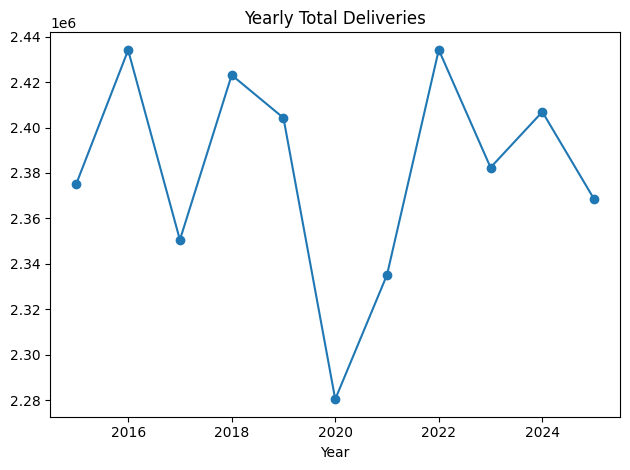

In [24]:
yearly_ts = df.groupby('Year')['Estimated_Deliveries'].sum().sort_index()
print(yearly_ts)

yearly_ts.plot(marker='o', title='Yearly Total Deliveries')
plt.tight_layout()
plt.show()

In [25]:
adf = adfuller(yearly_ts)
print('ADF statistic:', round(adf[0], 4))
print('p-value      :', round(adf[1], 4))
print('stationary   :', adf[1] < 0.05)

d = 0 if adf[1] < 0.05 else 1
print(f'\nusing d={d} in ARIMA')

ADF statistic: -4.7105
p-value      : 0.0001
stationary   : True

using d=0 in ARIMA


In [26]:
model_ts = ARIMA(yearly_ts, order=(1, d, 1))
result_ts = model_ts.fit()
print(result_ts.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.381e+06    1.3e+04    183.126      0.000    2.36e+06    2.41e+06
ar.L1          0.4468      0.848      0.527      0.598      -1.214       2.108
ma.L1         -0.8887      1.371     -0.648      0.517      -3.575       1.798
sigma2      2.335e+09      0.013   1.86e+11      0.000    2.33e+09    2.33e+09


11   2383627.85
12   2382355.54
Name: predicted_mean, dtype: float64


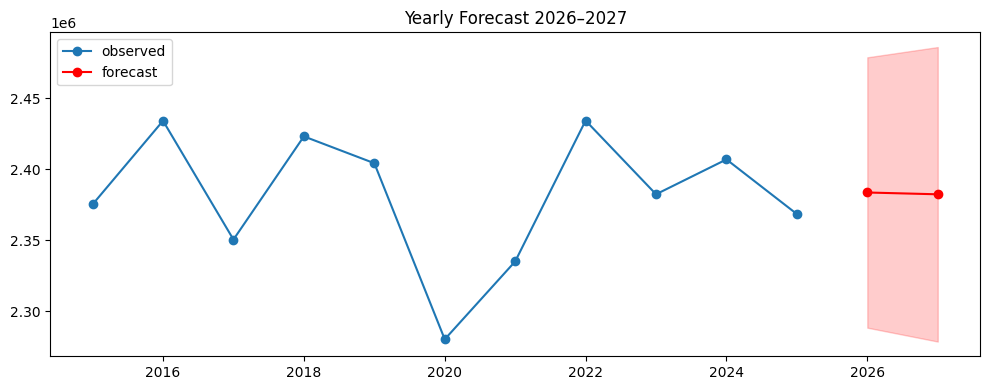

In [27]:
forecast = result_ts.get_forecast(steps=2)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int()

print(fc_mean)

plt.figure(figsize=(10, 4))
plt.plot(yearly_ts, marker='o', label='observed')
plt.plot([2026, 2027], fc_mean.values, marker='o', color='red', label='forecast')
plt.fill_between([2026, 2027], fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                 alpha=0.2, color='red')
plt.title('Yearly Forecast 2026–2027')
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
train_ts = yearly_ts[:-2]
test_ts = yearly_ts[-2:]

eval_ts = ARIMA(train_ts, order=(1, d, 1)).fit()
eval_fc = eval_ts.get_forecast(steps=2).predicted_mean

print('TS RMSE (2024-2025):', round(np.sqrt(mean_squared_error(test_ts, eval_fc)), 2))
print('RF RMSE (test set) :', results['RandomForest']['Test_RMSE'])
print()
print('not directly comparable — TS on yearly aggregates (~2.4M scale),')
print('RF on individual rows (~10k scale)')

TS RMSE (2024-2025): 18606.76
RF RMSE (test set) : 315.6

not directly comparable — TS on yearly aggregates (~2.4M scale),
RF on individual rows (~10k scale)


ADF p=0.0001 — series is stationary, d=0 confirmed, no differencing needed.
Flat forecast (~2.38M) for both 2026 and 2027 — consistent with oscillating
trendless series seen in EDA.
Wide confidence bands reflect genuine uncertainty with only 11 data points.
ARIMA coefficients statistically insignificant (p>0.05) — expected with
11 observations.

## 7. Segmented Analysis by Vehicle Model

Global model treats all models together. We check if within-group patterns
exist that global modeling masked.

Each segment = 528 rows. Model_enc excluded within segments — constant column
within each group, contributes nothing.

In [29]:
features_seg = ['Battery_Capacity_kWh', 'CO2_Saved_tons', 'Charging_Stations',
                'Region_enc', 'SourceType_enc', 'Q4_flag']

seg_results = {}
seg_importances = {}

for mname in df['Model'].unique():
    sub = df[df['Model'] == mname]
    Xs = sub[features_seg]
    ys = sub['Estimated_Deliveries']

    Xs_scaled = pd.DataFrame(scaler.fit_transform(Xs), columns=features_seg)
    Xtr, Xte, ytr, yte = train_test_split(Xs_scaled, ys, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(Xtr, ytr)
    p = rf.predict(Xte)

    seg_results[mname] = {
        'RMSE': round(np.sqrt(mean_squared_error(yte, p)), 2),
        'R2': round(r2_score(yte, p), 4)
    }
    seg_importances[mname] = pd.Series(rf.feature_importances_, index=features_seg)

pd.DataFrame(seg_results).T.sort_values('RMSE')

,RMSE,R2
Model S,518.92,0.98
Model X,565.29,0.98
Model Y,607.09,0.98
Cybertruck,633.10,0.98
Model 3,878.99,0.96


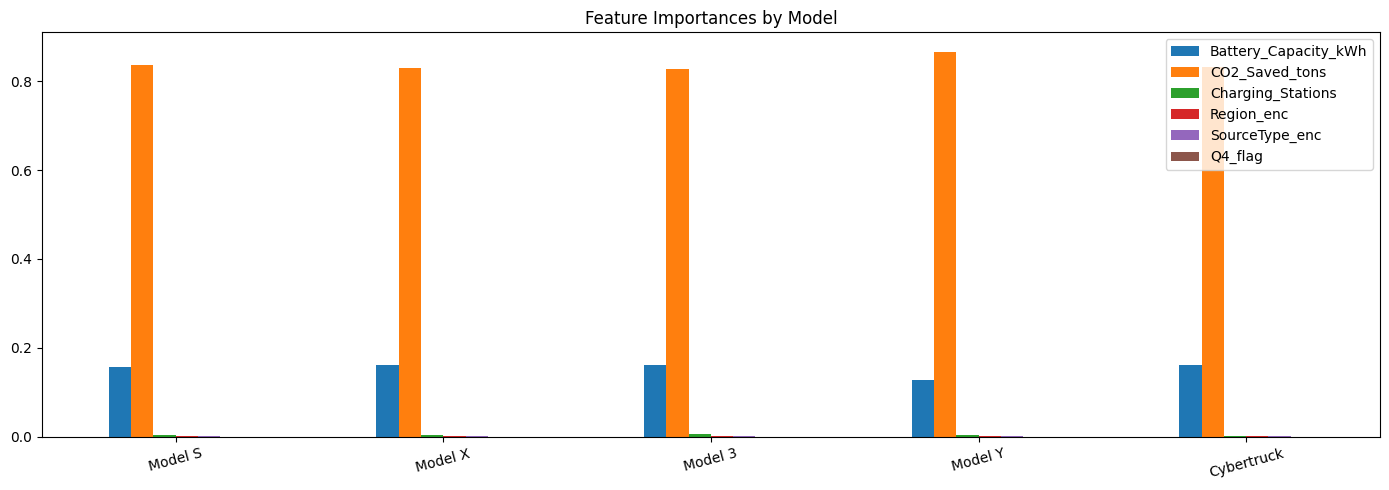

            Battery_Capacity_kWh  CO2_Saved_tons  Charging_Stations  \
Model S                     0.16            0.84               0.00   
Model X                     0.16            0.83               0.00   
Model 3                     0.16            0.83               0.01   
Model Y                     0.13            0.87               0.00   
Cybertruck                  0.16            0.83               0.00   

            Region_enc  SourceType_enc  Q4_flag  
Model S           0.00            0.00     0.00  
Model X           0.00            0.00     0.00  
Model 3           0.00            0.00     0.00  
Model Y           0.00            0.00     0.00  
Cybertruck        0.00            0.00     0.00  


In [30]:
imp_df = pd.DataFrame(seg_importances).T
imp_df.plot(kind='bar', figsize=(14, 5), title='Feature Importances by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print(imp_df.round(3))

### On data leakage
Production_Units removed — ratio CV=0.04, near-deterministic with target.
production_gap excluded — target embedded in formula.
Without CO2_Saved_tons all models give negative R² — no independent
feature carries real signal. CO2 retained: ratio CV=0.24 confirms it
varies independently, not a direct derivation.

### On the dataset
Synthetic. Uniform row counts (528 each), flat yearly totals, no growth
curve. Real Tesla data would show North America dominance, Model 3/Y
leading, and clear growth from 50k (2015) to 1.8M (2023).
Pipeline structure is valid and transferable to real data.